In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive/',force_remount=True)

Mounted at /content/drive/


In [ ]:
file_path_1 = '/content/drive/My Drive/Colab Notebooks/Content.csv'
file_path_2 = '/content/drive/My Drive/Colab Notebooks/Reactions.csv'
file_path_3 = '/content/drive/My Drive/Colab Notebooks/ReactionTypes.csv'
#Read the file

content_df = pd.read_csv(file_path_1)
Reactions_df = pd.read_csv(file_path_2)
ReactionTypes_df = pd.read_csv(file_path_3)


In [ ]:
content_df.head()

,Unnamed: 0,Content ID,User ID,Type,Category,URL
0,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,8d3cd87d-8a31-4935-9a4f-b319bfe05f31,photo,Studying,https://socialbuzz.cdn.com/content/storage/975...
1,1,9f737e0a-3cdd-4d29-9d24-753f4e3be810,beb1f34e-7870-46d6-9fc7-2e12eb83ce43,photo,healthy eating,https://socialbuzz.cdn.com/content/storage/9f7...
2,2,230c4e4d-70c3-461d-b42c-ec09396efb3f,a5c65404-5894-4b87-82f2-d787cbee86b4,photo,healthy eating,https://socialbuzz.cdn.com/content/storage/230...
3,3,356fff80-da4d-4785-9f43-bc1261031dc6,9fb4ce88-fac1-406c-8544-1a899cee7aaf,photo,technology,https://socialbuzz.cdn.com/content/storage/356...
4,4,01ab84dd-6364-4236-abbb-3f237db77180,e206e31b-5f85-4964-b6ea-d7ee5324def1,video,food,https://socialbuzz.cdn.com/content/storage/01a...


In [ ]:
Reactions_df.head()

,Unnamed: 0,Content ID,User ID,Type,Datetime
0,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,NaN,NaN,2021-04-22 15:17:15
1,1,97522e57-d9ab-4bd6-97bf-c24d952602d2,5d454588-283d-459d-915d-c48a2cb4c27f,disgust,2020-11-07 09:43:50
2,2,97522e57-d9ab-4bd6-97bf-c24d952602d2,92b87fa5-f271-43e0-af66-84fac21052e6,dislike,2021-06-17 12:22:51
3,3,97522e57-d9ab-4bd6-97bf-c24d952602d2,163daa38-8b77-48c9-9af6-37a6c1447ac2,scared,2021-04-18 05:13:58
4,4,97522e57-d9ab-4bd6-97bf-c24d952602d2,34e8add9-0206-47fd-a501-037b994650a2,disgust,2021-01-06 19:13:01


In [ ]:
ReactionTypes_df.head()

,Unnamed: 0,Type,Sentiment,Score
0,0,heart,positive,60
1,1,want,positive,70
2,2,disgust,negative,0
3,3,hate,negative,5
4,4,interested,positive,30


In [ ]:
#delete userID and URL for content_df
content_df = content_df.drop(['User ID','URL'], axis=1)
content_df.head()

,Unnamed: 0,Content ID,Type,Category
0,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying
1,1,9f737e0a-3cdd-4d29-9d24-753f4e3be810,photo,healthy eating
2,2,230c4e4d-70c3-461d-b42c-ec09396efb3f,photo,healthy eating
3,3,356fff80-da4d-4785-9f43-bc1261031dc6,photo,technology
4,4,01ab84dd-6364-4236-abbb-3f237db77180,video,food


In [ ]:
#remove quotation marks in column Type in content_df
content_df['Type'] = content_df['Type'].str.replace('"','')


KeyError: 'Type'

In [ ]:
#delete column user ID in Reactions_df
Reactions_df = Reactions_df.drop(['User ID'], axis=1)
#delete row where reaction value is NaN
Reactions_df = Reactions_df.dropna()


,Unnamed: 0,Content ID,Type,Datetime
1,1,97522e57-d9ab-4bd6-97bf-c24d952602d2,disgust,2020-11-07 09:43:50
2,2,97522e57-d9ab-4bd6-97bf-c24d952602d2,dislike,2021-06-17 12:22:51
3,3,97522e57-d9ab-4bd6-97bf-c24d952602d2,scared,2021-04-18 05:13:58
4,4,97522e57-d9ab-4bd6-97bf-c24d952602d2,disgust,2021-01-06 19:13:01
5,5,97522e57-d9ab-4bd6-97bf-c24d952602d2,interested,2020-08-23 12:25:58


In [ ]:
#change column name Type content_df to content Type
content_df = content_df.rename(columns={'Type': 'Content Type'})


,Unnamed: 0,Content ID,Content Type,Category
0,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying
1,1,9f737e0a-3cdd-4d29-9d24-753f4e3be810,photo,healthy eating
2,2,230c4e4d-70c3-461d-b42c-ec09396efb3f,photo,healthy eating
3,3,356fff80-da4d-4785-9f43-bc1261031dc6,photo,technology
4,4,01ab84dd-6364-4236-abbb-3f237db77180,video,food


In [ ]:
#change column Type in Reactions_df and ReactionsType_df into Reaction Type
Reactions_df = Reactions_df.rename(columns={'Type': 'Reaction Type'})
ReactionTypes_df = ReactionTypes_df.rename(columns={'Type': 'Reaction Type'})

In [ ]:
#merge all 3 dataframe together
merged_df = pd.merge(content_df, Reactions_df, on='Content ID')
merged_df = pd.merge(merged_df, ReactionTypes_df, on='Reaction Type')

In [ ]:
merged_df.head()

,Unnamed: 0_x,Content ID,Content Type,Category,Unnamed: 0_y,Reaction Type,Datetime,Unnamed: 0,Sentiment,Score
0,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,1,disgust,2020-11-07 09:43:50,2,negative,0
1,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,2,dislike,2021-06-17 12:22:51,11,negative,10
2,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,3,scared,2021-04-18 05:13:58,14,negative,15
3,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,4,disgust,2021-01-06 19:13:01,2,negative,0
4,0,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,5,interested,2020-08-23 12:25:58,4,positive,30


In [ ]:
#delete unnamed columns
merged_df = merged_df.loc[:, ~merged_df.columns.str.contains('^Unnamed')]

In [ ]:
merged_df.head()

,Content ID,Content Type,Category,Reaction Type,Datetime,Sentiment,Score
0,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,disgust,2020-11-07 09:43:50,negative,0
1,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,dislike,2021-06-17 12:22:51,negative,10
2,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,scared,2021-04-18 05:13:58,negative,15
3,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,disgust,2021-01-06 19:13:01,negative,0
4,97522e57-d9ab-4bd6-97bf-c24d952602d2,photo,Studying,interested,2020-08-23 12:25:58,positive,30


In [ ]:
#export the merged data frame as name "Final Data" as csv file and save it to drive
merged_df.to_csv('/content/drive/My Drive/Colab Notebooks/Final Data.csv')

In [ ]:
from google.colab import files
files.download('/content/drive/My Drive/Colab Notebooks/Final Data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
top_categories = merged_df.groupby("Category")["Score"].sum().nlargest(5)
top_categories.head()

,Score
Category,
animals,69548
healthy eating,69067
technology,67472
science,66043
cooking,63982


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

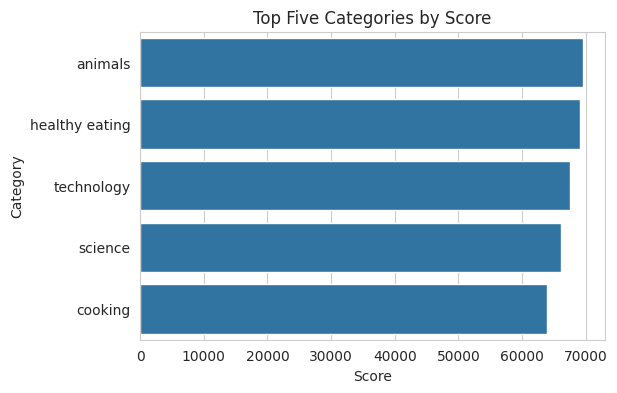

In [ ]:
#use seaborn to create a histogram showing the top five category and score and the color to be orange
sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title("Top Five Categories by Score")
plt.xlabel("Score")
plt.ylabel("Category")
plt.show()

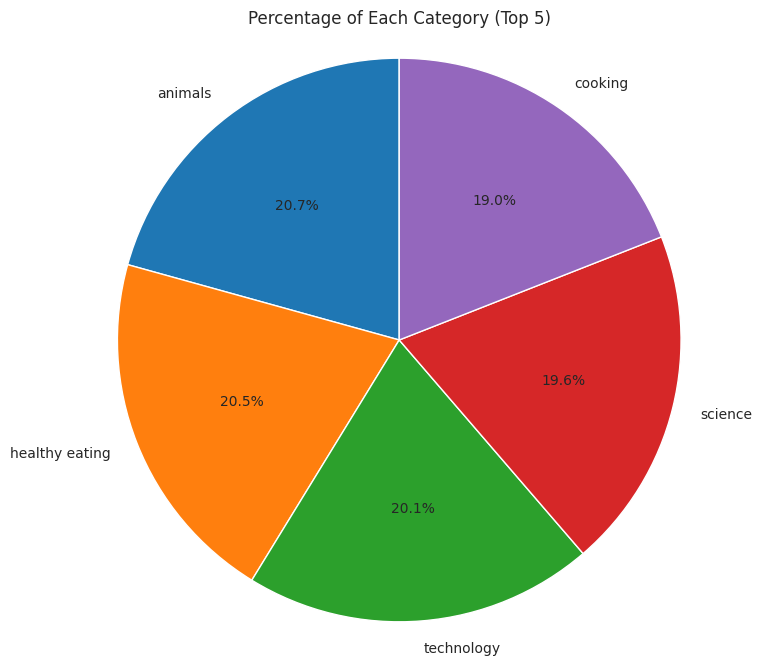

In [ ]:
#create a pie chart showing percentge of each category
plt.figure(figsize=(8, 8))  # Adjust figure size as needed
plt.pie(top_categories, labels=top_categories.index, autopct='%1.1f%%', startangle=90)
plt.title('Percentage of Each Category (Top 5)')
plt.axis('equal')

plt.show()
